# Extension: Reaction Time Analysis Pipeline of Jan Hagnberger and Jianyang Gu

This Jupyter Notebook contains the extension for the course project in "Signal processing and Analysis of human brain potentials (EEG)" at the University of Stuttgart in WS25/26. The goal of this pipeline is to analyze the reaction times provided in the data of the paper "[Detecting Visuo-Haptic Mismatches in Virtual Reality using the Prediction Error Negativity of Event-Related Brain Potentials](https://dl.acm.org/doi/10.1145/3290605.3300657)" by Gehrke et al., 2019. We use the data the authors' published on [OpenNeuro (Dataset ds003846)](https://openneuro.org/datasets/ds003846/versions/1.0.1). 


The Jupyter Notebook mainly uses the structure of our main pipeline (`erp_analysis.ipynb`) which is structured as follows:
- **Helper functions**: We define functions for loading the data, preprocessing the EEG signals, and performing the analysis. Each function is documented with a docstring that explains its purpose, inputs, and outputs.
- **Build Pipeline**: Combines all helper functions into a single pipeline that can be easily executed to reproduce the results of the paper. The pipeline includes steps for loading the data, preprocessing it, and creating the epoched data.
- **Run Pipeline**: Executes the pipeline for all subjects and sessions in the dataset, and plots intermediate results if required.
- **Plotting**: Finally, we plot the grand-average of the beta conditions and centered reaction time.



In [22]:
import mne
import numpy as np
from matplotlib import pyplot as plt
from mne_bids import BIDSPath, read_raw_bids
import os
import shutil
from joblib import Parallel, delayed
import pandas as pd
from mne.stats import linear_regression

## Load Helper Functions

In [23]:
from reactiontime_analysis_functions import remove_problematic_annotations, get_available_sessions, load_data, remove_bad_channels, filtering_referencing, apply_ica_eyes, make_epoched_data, make_glm, make_grand_average_plot

## Build the Pipeline

In [24]:
def process_subject(bids_root="/Users/jan/Documents/git/ds003846", subject_id="02", show_intermediate_plots=False):
    """Pipeline for processing one subject across all sessions. The pipeline includes loading the data, removing bad
    channels, filtering and re-referencing, applying ICA to remove eye movement artifacts, and finally creating beta
    plots for the condition and reaction time predictors of the GLM analysis. The function returns the raw data to
    plot the final grand-average for all sessions.
    
    Args:
        bids_root: The root path to the BIDS dataset.
        subject_id: The ID of the subject (e.g., "02") as string.
        show_intermediate_plots: Whether to show intermediate plots.
    
    Returns:
        Tuple of
            - Subject ID
            - Beta condition data 
            - Beta centered reaction time data
    """
    
    mne.set_log_level('WARNING')
    
    beta_condition_data = {}
    beta_rt_data = {}
    sessions = get_available_sessions(bids_root=bids_root, subject_id=subject_id)
    print(f"Available sessions for subject {subject_id}: {sessions}")
    
    for session in sessions:
        print(f"Session: {session}")
        # 1. Load data
        data = load_data(bids_root=bids_root, subject_id=subject_id, session=session)
        
        # Plot raw data before and after preprocessing
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # 2. Remove bad channels manually
        remove_bad_channels(data, int(subject_id))

        # Remove bad events manually
        # We also skip this step for the sake of simplicity and because the results are already good without it.
        
        # 3. Filtering
        data = filtering_referencing(data, show_plots=show_intermediate_plots)
        
        # Plot better data
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # 4. Apply ICA
        data = apply_ica_eyes(data, show_plots=show_intermediate_plots)
        
        # Plot after ICA
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # Apply ASR to remove remaining artifacts
        # We skip this step because ASR was extremely slow and the results are also good without it.
        
        # 5. Create epoched data for GLM
        epochs_normal, reaction_times_normal = make_epoched_data(data, condition="normal")
        epochs_conflict, reaction_times_conflict = make_epoched_data(data, condition="conflict")
        
        # Plot reaction times as histogram in one plot for both conditions for subject 04 as an example
        if subject_id == "04":
            plt.figure(figsize=(7, 3))
            plt.hist(reaction_times_normal, bins=int(np.sqrt(len(reaction_times_normal))), color="blue", alpha=0.7, label="Normal")
            plt.hist(reaction_times_conflict, bins=int(np.sqrt(len(reaction_times_conflict))), color="orange", alpha=0.7, label="Conflict")
            plt.title(f"Reaction Times for Subject {subject_id}, Condition: {session}")
            plt.xlabel("Reaction Time (s)")
            plt.ylabel("Count")
            plt.legend()
            plt.tight_layout()
            plt.savefig(f"reaction_times_{subject_id}_{session}.pdf", format="pdf")
            plt.show()
        
        # 6. GLM analysis with reaction times
        if len(epochs_normal) == len(reaction_times_normal) and len(epochs_conflict) == len(reaction_times_conflict):
            beta_condition, beta_rt = make_glm(epochs_normal, epochs_conflict, reaction_times_normal, reaction_times_conflict, show_plots=show_intermediate_plots)
        
            beta_condition_data[session] = beta_condition
            beta_rt_data[session] = beta_rt
        
    return subject_id, beta_condition_data, beta_rt_data

# Run the Pipeline

In [25]:
# Set the dataset path and subjects here 

DATASET_PATH = "/Users/jan/Documents/git/ds003846"
#subjects = ["02"]
subjects = [f"{i:02d}" for i in range(2, 21) if (i != 3)] # exclude subject 03 because of splitted sessions
print(subjects)
show_intermediate_plots = False

['02', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [26]:
# Remove the problematic columns from participants.tsv
remove_problematic_annotations(bids_root=DATASET_PATH)

if not show_intermediate_plots:
    # Run the pipeline for each subject in parallel. This is necessary because doing it sequentially takes too much time
    # This only works if we do not want intermediate plots
    output = Parallel(n_jobs=4)(delayed(process_subject)(bids_root=DATASET_PATH, subject_id=subject, show_intermediate_plots=show_intermediate_plots) for subject in subjects)
else:
    # Run the pipeline for each subject sequentially
    # This is needed if we want to show intermediate plots
    output = []
    for subject in subjects:
        result = process_subject(bids_root=DATASET_PATH, subject_id=subject, show_intermediate_plots=show_intermediate_plots)
        output.append(result)

# Store the final results
beta_type_all = {}
beta_rt_all = {}

for subject_id, beta_type, beta_rt in output:
    beta_type_all[subject_id] = beta_type
    beta_rt_all[subject_id] = beta_rt

Available sessions for subject 02: ['EMS', 'Visual', 'Vibro']
Session: EMS
Available sessions for subject 04: ['Visual', 'Vibro']
Session: Visual
Available sessions for subject 05: ['Visual', 'Vibro']
Session: Visual
Available sessions for subject 06: ['EMS', 'Visual', 'Vibro']
Session: EMS


/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Visual


/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Visual


...

/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])
/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Vibro


/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Vibro


/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])
/Users/jan/Documents/git/eeg/reactiontime_analysis_functions.py:310: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


# Plotting

### Plot Betas for Single Subjects and Sessions
We plot the betas for each single subject and session separately to check if there are some obvious issues with the data.

Session EMS and subject 02
Need more than one channel to make topography for eeg. Disabling interactivity.


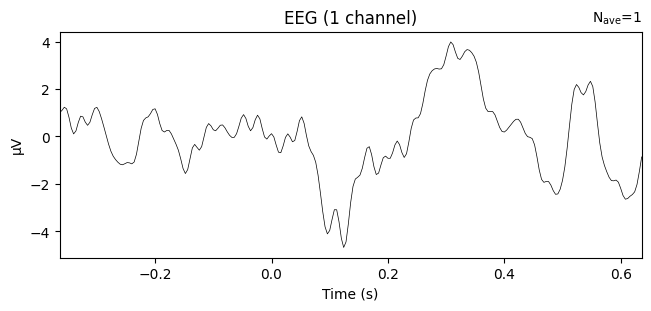

Session EMS and subject 06
Need more than one channel to make topography for eeg. Disabling interactivity.


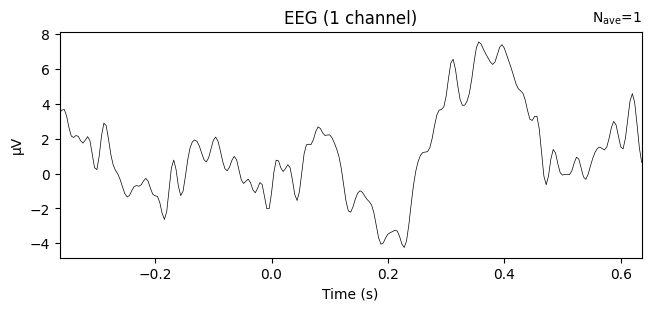

Session EMS and subject 07
Need more than one channel to make topography for eeg. Disabling interactivity.


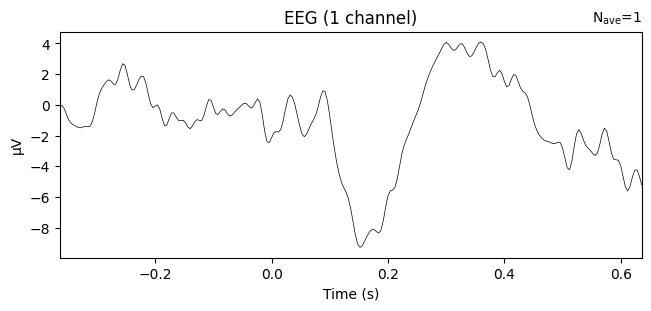

Session EMS and subject 08
Need more than one channel to make topography for eeg. Disabling interactivity.


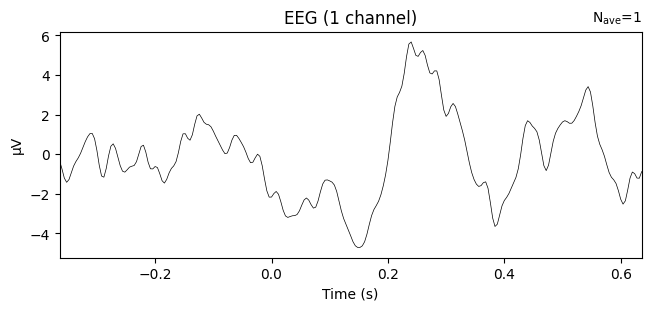

Session EMS and subject 11
Need more than one channel to make topography for eeg. Disabling interactivity.


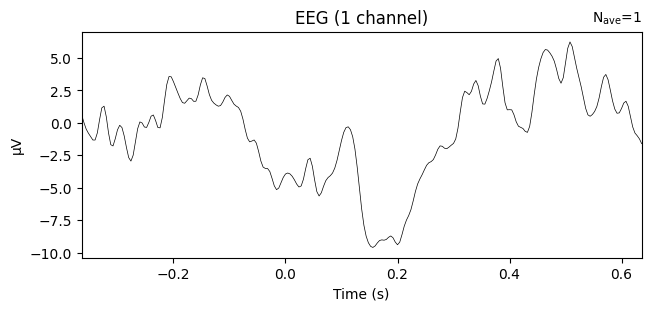

Session EMS and subject 12
Need more than one channel to make topography for eeg. Disabling interactivity.


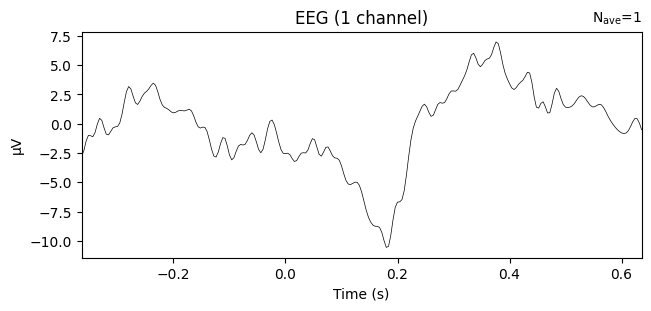

Session EMS and subject 13
Need more than one channel to make topography for eeg. Disabling interactivity.


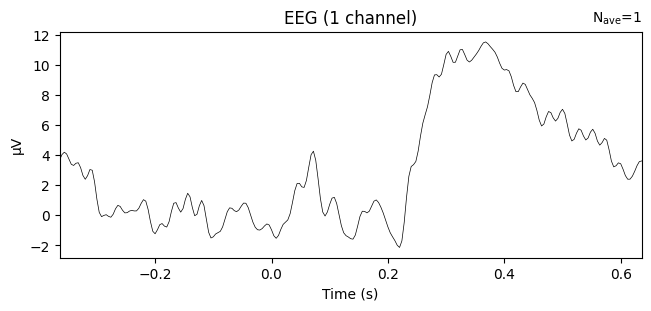

Session EMS and subject 14
Need more than one channel to make topography for eeg. Disabling interactivity.


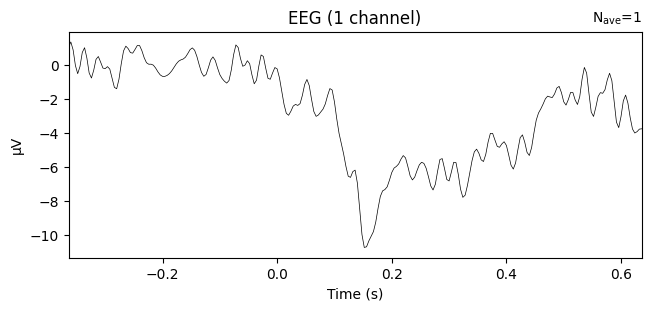

Session EMS and subject 15
Need more than one channel to make topography for eeg. Disabling interactivity.


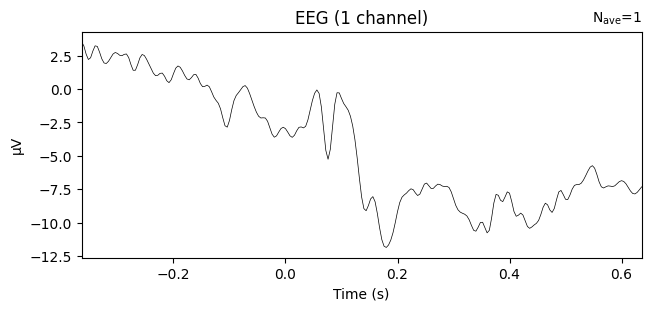

Number of evokeds for type: 17, rt: 17
Identifying common channels ...
Identifying common channels ...


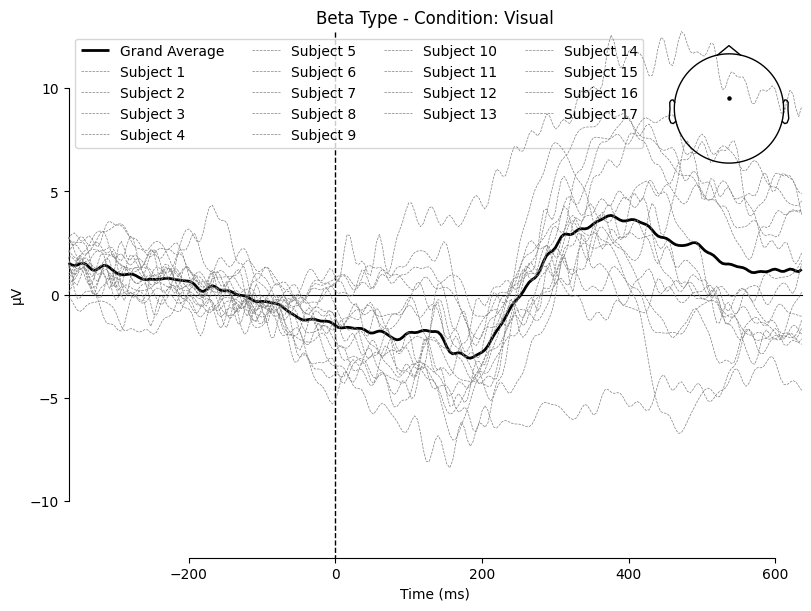

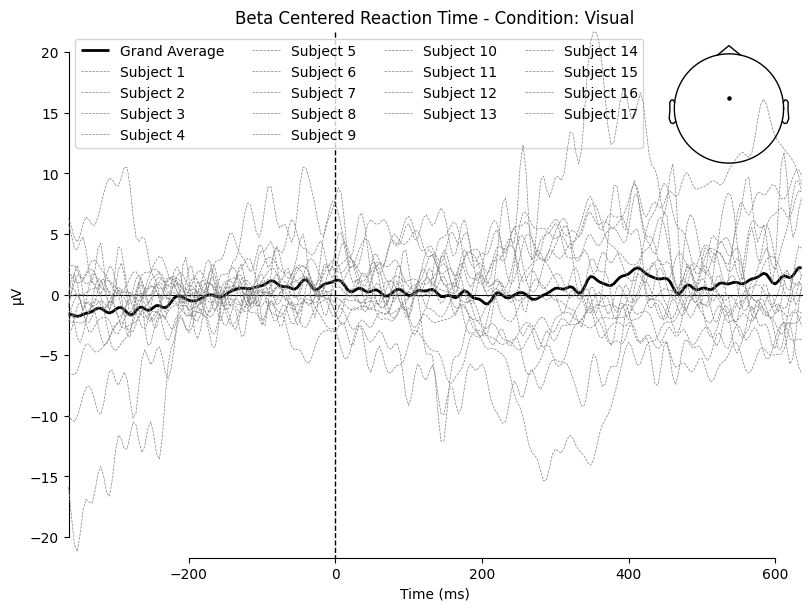

Number of evokeds for type: 16, rt: 16
Identifying common channels ...
Identifying common channels ...


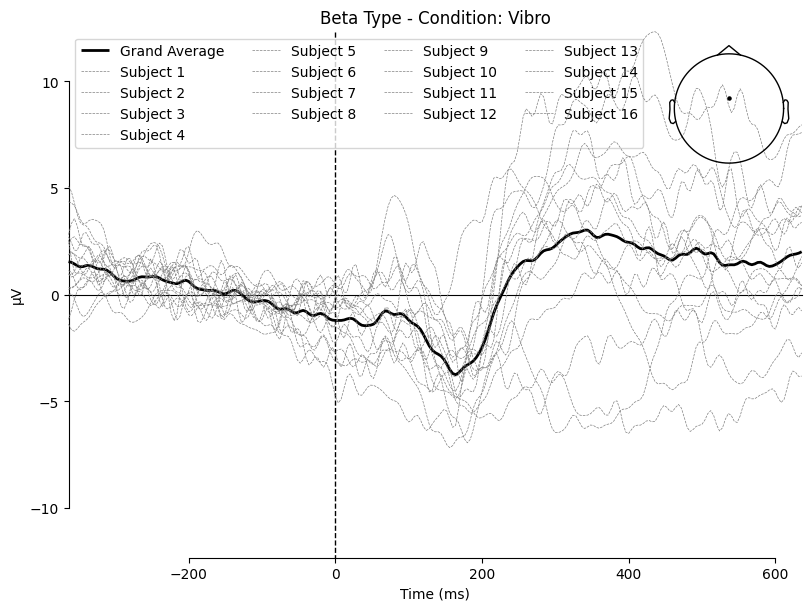

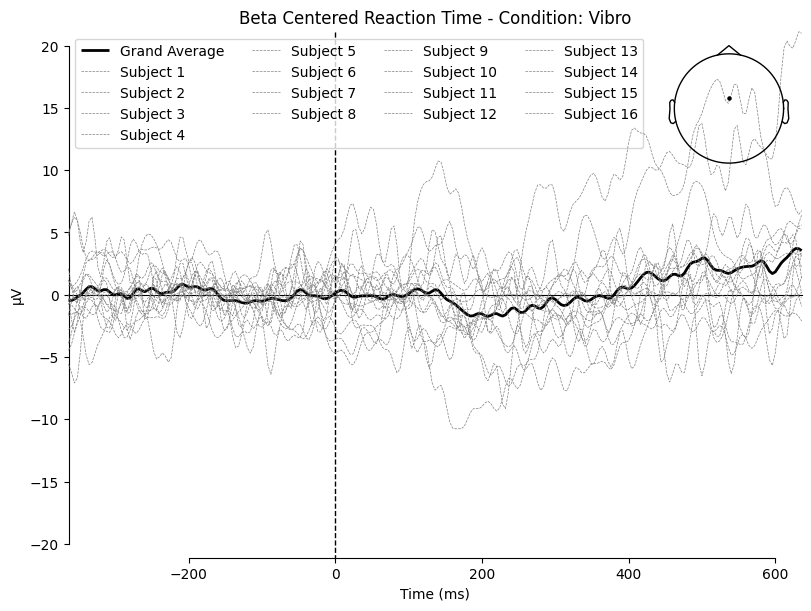

Number of evokeds for type: 9, rt: 9
Identifying common channels ...
Identifying common channels ...


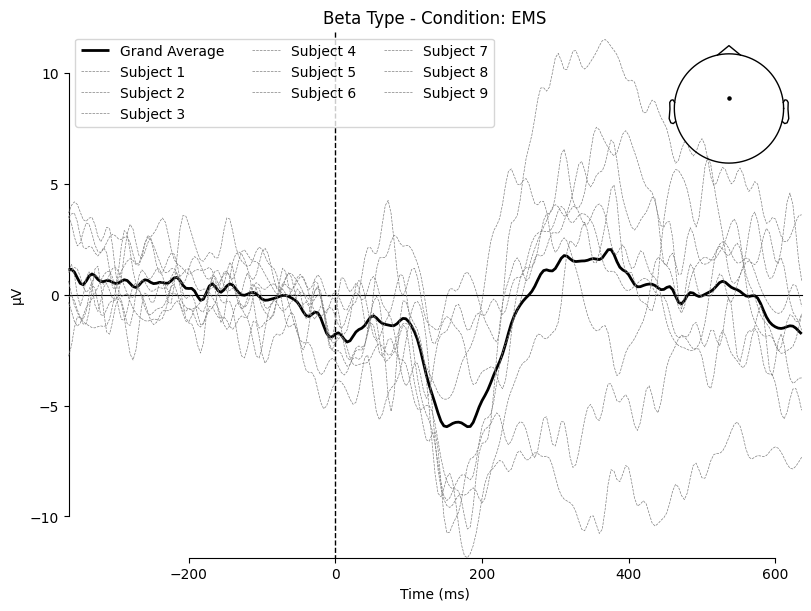

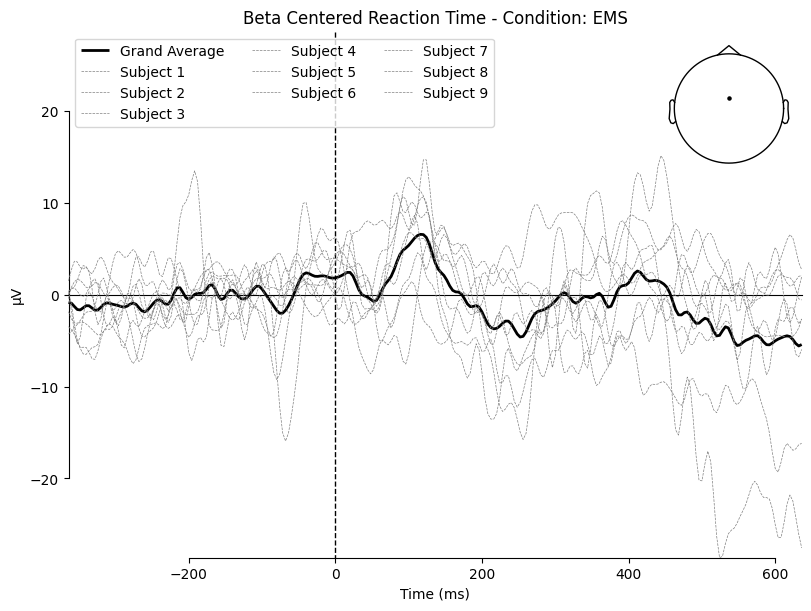

In [27]:
# Plot individual subjects and sessions. We only plot EMS to reduce the number of plots.
for session in ["EMS"]:
    subjects = beta_type_all.keys()
    for subject in subjects:
        if session in beta_type_all[subject]:
            print(f"Session {session} and subject {subject}")
            beta_type_all[subject][session].plot()


# Plot grand average with individual subjects
line_width = 0.5  # Set a smaller line width for individual subjects

for session in ["Visual", "Vibro", "EMS"]:
    beta_type_all_list = list(beta_type_all.values())
    beta_rt_all_list = list(beta_rt_all.values())
    evokeds_beta_type = [beta_type_all_list[i][session] for i in range(len(beta_type_all_list)) if session in beta_type_all_list[i]]
    evokeds_beta_rt = [beta_rt_all_list[i][session] for i in range(len(beta_rt_all_list)) if session in beta_rt_all_list[i]]
    
    subject_lines_type = {f"Subject {i+1}": {"linewidth": line_width} for i in range(len(evokeds_beta_type))}
    subject_lines_rt = {f"Subject {i+1}": {"linewidth": line_width} for i in range(len(evokeds_beta_rt))}
    
    print(f"Number of evokeds for type: {len(evokeds_beta_type)}, rt: {len(evokeds_beta_rt)}")
    grand_average_type = mne.grand_average(evokeds_beta_type)
    grand_average_time = mne.grand_average(evokeds_beta_rt)
    
    # Plot for normal condition
    fig = mne.viz.plot_compare_evokeds(
        {"Grand Average": grand_average_type, 
        **{f"Subject {i+1}": evoked for i, evoked in enumerate(evokeds_beta_type)}},
        picks="FCz",
        time_unit="ms",
        colors={"Grand Average": "black"},  # Use the same color for all subjects
        linestyles={"Grand Average": "-", **{f"Subject {i+1}": "--" for i in range(len(evokeds_beta_type))}},
        styles={"Grand Average": {"linewidth": 2}, **subject_lines_type},
        title=f"Beta Type - Condition: {session}"
    )[0]
    fig.set_size_inches(6, 4)
    fig.savefig(f"grand_individual_type_{session}.pdf", format="pdf")

    # Plot for conflict condition
    fig = mne.viz.plot_compare_evokeds(
        {"Grand Average": grand_average_time,
        **{f"Subject {i+1}": evoked for i, evoked in enumerate(evokeds_beta_rt)}},
        picks="FCz",
        time_unit="ms",
        colors={"Grand Average": "black"},  # Use the same color for all subjects
        linestyles={"Grand Average": "-", **{f"Subject {i+1}": "--" for i in range(len(evokeds_beta_rt))}},
        styles={"Grand Average": {"linewidth": 2}, **subject_lines_rt},
        title=f"Beta Centered Reaction Time - Condition: {session}"
    )[0]
    fig.set_size_inches(6, 4)
    fig.savefig(f"grand_individual_rt_{session}.pdf", format="pdf")

### Exclude Subject 16 and Plot Grand Average Beta

In [28]:
# Exclude subject 16
beta_type_excluded = {}
beta_rt_excluded = {}

for subject, data in beta_type_all.items():
    if subject != "16":
        beta_type_excluded[subject] = data

for subject, data in beta_rt_all.items():
    if subject != "16":
        beta_rt_excluded[subject] = data
        

Number of evokeds for type: 17, reaction time: 17
Identifying common channels ...
Identifying common channels ...
Number of evokeds for type: 16, reaction time: 16
Identifying common channels ...
Identifying common channels ...
Number of evokeds for type: 9, reaction time: 9
Identifying common channels ...
Identifying common channels ...


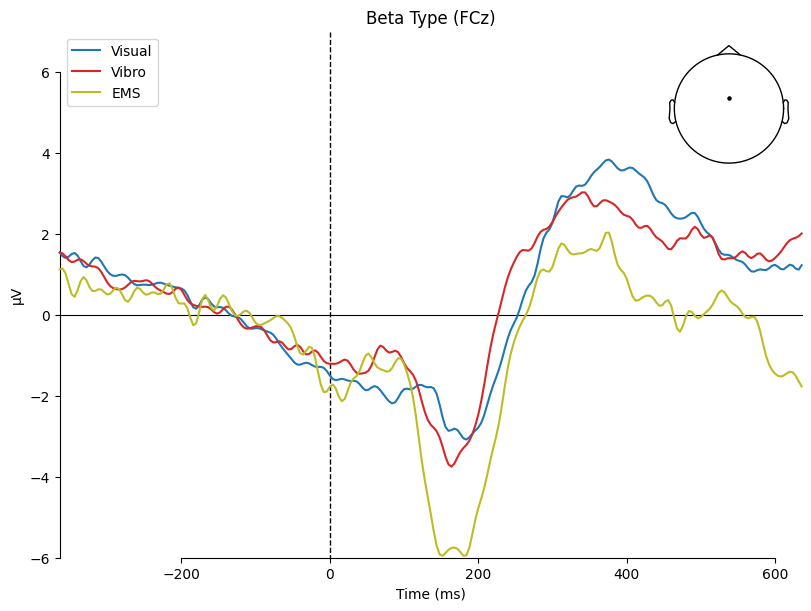

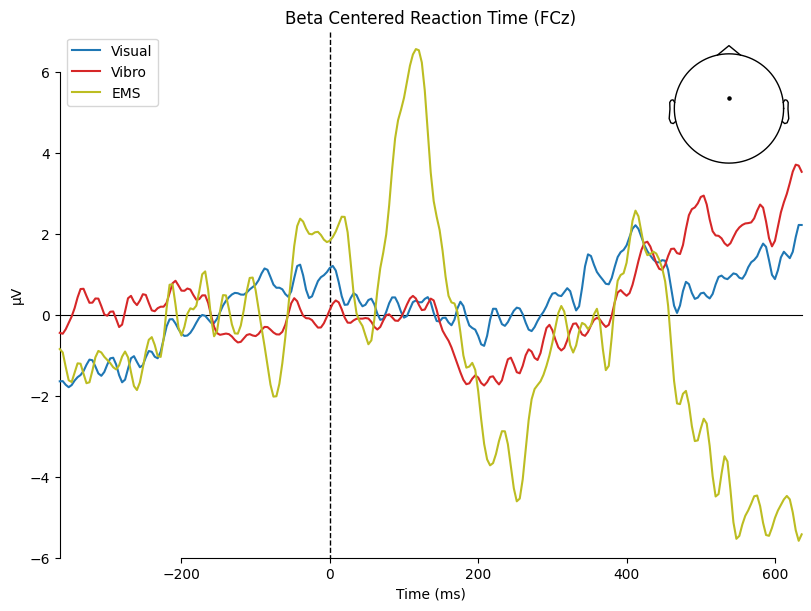

In [29]:
# Plot only grand average and no single subjects
grand_average_type_sess = {}
grand_average_rt_sess = {}

# Average across subjects and plot
for session in ["Visual", "Vibro", "EMS"]:
    normal_data_all_list = list(beta_type_excluded.values())
    conflict_data_all_list = list(beta_rt_excluded.values())
    
    evokeds_type = [normal_data_all_list[i][session] for i in range(len(normal_data_all_list)) if session in normal_data_all_list[i]]
    evokeds_rt = [conflict_data_all_list[i][session] for i in range(len(conflict_data_all_list)) if session in conflict_data_all_list[i]]
    
    print(f"Number of evokeds for type: {len(evokeds_type)}, reaction time: {len(evokeds_rt)}")
    grand_average_type = mne.grand_average(evokeds_type)
    grand_average_rt = mne.grand_average(evokeds_rt)
    
    grand_average_type_sess[session] = grand_average_type
    grand_average_rt_sess[session] = grand_average_rt

make_grand_average_plot(grand_average_type_sess, grand_average_rt_sess)